# 04 — FAG-TFT Classifier
### Frequency-Aware Gated Temporal Fusion Transformer
> Run 00_Data_Preparation.ipynb first.


In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')


✅ Device: cpu


In [2]:
with open('prepared_classification.pkl','rb') as f: d = pickle.load(f)
with open('encoder.pkl','rb') as f: encoder = pickle.load(f)

X_train    = torch.FloatTensor(d['X_train_seq']).to(DEVICE)
X_test     = torch.FloatTensor(d['X_test_seq']).to(DEVICE)
y_train    = torch.LongTensor(d['y_train_seq']).to(DEVICE)
y_test     = torch.LongTensor(d['y_test_seq']).to(DEVICE)

NUM_CLASSES   = d['num_classes']
NUM_FEATURES  = d['num_features']
TIME_STEPS    = d['TIME_STEPS']
feature_names = d['feature_names']

G1_IDX = list(range(0,  9))   # Low Freq  (10-100Hz)  — 9 bands
G2_IDX = list(range(9,  29))  # Mid Freq  (100-300Hz) — 20 bands
G3_IDX = list(range(29, 60))  # High Freq (300-610Hz) — 31 bands
EL_IDX = list(range(60, 67))  # Electrical + time_gap — 7 features

# Class weights from balanced training data
class_counts   = np.bincount(d['y_train_seq'])
class_weights  = 1.0 / class_counts
class_weights  = class_weights / class_weights.sum() * len(class_counts)
weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

print(f'✅ Data loaded.')
print(f'   G1 Low Freq  (10-100Hz)  : {len(G1_IDX)} bands')
print(f'   G2 Mid Freq  (100-300Hz) : {len(G2_IDX)} bands')
print(f'   G3 High Freq (300-610Hz) : {len(G3_IDX)} bands')
print(f'   Electrical               : {len(EL_IDX)} features')
print(f'   Train class counts       : {class_counts}')
print(f'   Test  class counts       : {np.bincount(d["y_test_seq"])}')


✅ Data loaded.
   G1 Low Freq  (10-100Hz)  : 9 bands
   G2 Mid Freq  (100-300Hz) : 20 bands
   G3 High Freq (300-610Hz) : 31 bands
   Electrical               : 7 features
   Train class counts       : [2310  776  770  776]
   Test  class counts       : [9397  197  169  217]


---
## FAG-TFT Classifier
> Novel contribution: Frequency-Aware Gated TFT with Hierarchical VSN.
> hidden_size=16, num_heads=2, 1 LSTM layer, dropout=0.4


In [3]:
class GRN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super().__init__()
        self.fc1        = nn.Linear(input_size, hidden_size)
        self.fc2        = nn.Linear(hidden_size, output_size)
        self.gate_fc    = nn.Linear(hidden_size, output_size)
        self.elu        = nn.ELU()
        self.sigmoid    = nn.Sigmoid()
        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(output_size)
        self.residual   = nn.Linear(input_size, output_size) if input_size != output_size else nn.Identity()

    def forward(self, x):
        h    = self.elu(self.fc1(x))
        h    = self.dropout(h)
        gate = self.sigmoid(self.gate_fc(h))
        out  = gate * self.fc2(h)
        return self.layer_norm(out + self.residual(x))


class HierarchicalVSN(nn.Module):
    def __init__(self, g1_size, g2_size, g3_size, el_size, hidden_size, dropout=0.1):
        super().__init__()
        self.grn_g1 = GRN(g1_size, hidden_size, hidden_size, dropout)
        self.grn_g2 = GRN(g2_size, hidden_size, hidden_size, dropout)
        self.grn_g3 = GRN(g3_size, hidden_size, hidden_size, dropout)
        self.grn_el = GRN(el_size, hidden_size, hidden_size, dropout)
        self.sel_g1 = nn.Linear(hidden_size, hidden_size)
        self.sel_g2 = nn.Linear(hidden_size, hidden_size)
        self.sel_g3 = nn.Linear(hidden_size, hidden_size)
        self.sel_el = nn.Linear(hidden_size, hidden_size)
        self.across_grn  = GRN(hidden_size * 4, hidden_size, 4, dropout)
        self.group_merge = nn.Linear(hidden_size * 4, hidden_size)

    def forward(self, x_g1, x_g2, x_g3, x_el):
        h1 = self.grn_g1(x_g1); h2 = self.grn_g2(x_g2)
        h3 = self.grn_g3(x_g3); he = self.grn_el(x_el)
        w1 = torch.sigmoid(self.sel_g1(h1)); w2 = torch.sigmoid(self.sel_g2(h2))
        w3 = torch.sigmoid(self.sel_g3(h3)); we = torch.sigmoid(self.sel_el(he))
        h1, h2, h3, he = w1*h1, w2*h2, w3*h3, we*he
        concat    = torch.cat([h1, h2, h3, he], dim=-1)
        g_weights = F.softmax(self.across_grn(concat), dim=-1)
        self.group_weights = g_weights.detach().cpu()
        merged = (g_weights[:,0:1]*h1 + g_weights[:,1:2]*h2 +
                  g_weights[:,2:3]*h3 + g_weights[:,3:4]*he)
        return self.group_merge(concat) + merged


class FAG_TFT(nn.Module):
    def __init__(self, g1_size, g2_size, g3_size, el_size,
                 time_steps, num_classes, hidden_size=16, num_heads=2, dropout=0.4):
        super().__init__()
        self.time_steps = time_steps
        self.g1_size = g1_size; self.g2_size = g2_size
        self.g3_size = g3_size; self.el_size = el_size
        self.vsn           = HierarchicalVSN(g1_size, g2_size, g3_size, el_size, hidden_size, dropout)
        # 1 LSTM layer — simpler, less prone to overfitting
        self.lstm_encoder  = nn.LSTM(hidden_size, hidden_size, 1, batch_first=True)
        self.attention     = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.attn_norm     = nn.LayerNorm(hidden_size)
        self.post_attn_grn = GRN(hidden_size, hidden_size, hidden_size, dropout)
        self.classifier    = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        vsn_out = []
        for t in range(self.time_steps):
            xt = x[:, t, :]
            g1 = xt[:, :self.g1_size]
            g2 = xt[:, self.g1_size:self.g1_size+self.g2_size]
            g3 = xt[:, self.g1_size+self.g2_size:self.g1_size+self.g2_size+self.g3_size]
            el = xt[:, self.g1_size+self.g2_size+self.g3_size:]
            vsn_out.append(self.vsn(g1, g2, g3, el))
        vsn_seq     = torch.stack(vsn_out, dim=1)
        lstm_out, _ = self.lstm_encoder(vsn_seq)
        attn_out, self.attn_weights = self.attention(lstm_out, lstm_out, lstm_out)
        attn_out    = self.attn_norm(attn_out + lstm_out)
        out         = self.post_attn_grn(attn_out[:, -1, :])
        return self.classifier(out)

    def get_group_importance(self):
        return self.vsn.group_weights.mean(dim=0).numpy()


tft_model = FAG_TFT(
    g1_size=len(G1_IDX), g2_size=len(G2_IDX),
    g3_size=len(G3_IDX), el_size=len(EL_IDX),
    time_steps=TIME_STEPS, num_classes=NUM_CLASSES,
    hidden_size=16, num_heads=2, dropout=0.4
).to(DEVICE)
print(f'FAG-TFT parameters: {sum(p.numel() for p in tft_model.parameters()):,}')


FAG-TFT parameters: 12,632


Training FAG-TFT Classifier...
Epoch   1 | Train: 0.6071 | Val: 0.1786
Epoch   2 | Train: 0.1617 | Val: 0.0651
Epoch   3 | Train: 0.1114 | Val: 0.0825
Epoch   4 | Train: 0.1063 | Val: 0.0795
Epoch   5 | Train: 0.0877 | Val: 0.0944
Epoch   6 | Train: 0.0815 | Val: 0.0689
Epoch   7 | Train: 0.0966 | Val: 0.0641
Epoch   8 | Train: 0.0714 | Val: 0.0633
Epoch   9 | Train: 0.0854 | Val: 0.0881
Epoch  10 | Train: 0.0723 | Val: 0.1110
Epoch  11 | Train: 0.0815 | Val: 0.0784
Epoch  12 | Train: 0.0769 | Val: 0.0898
Epoch  13 | Train: 0.0790 | Val: 0.0717
Epoch  14 | Train: 0.0692 | Val: 0.0847
Epoch  15 | Train: 0.0596 | Val: 0.0742
Epoch  16 | Train: 0.0710 | Val: 0.0898
Epoch  17 | Train: 0.0650 | Val: 0.0781
Epoch  18 | Train: 0.0578 | Val: 0.0848
Epoch  19 | Train: 0.0698 | Val: 0.0781
Epoch  20 | Train: 0.0639 | Val: 0.0811
Epoch  21 | Train: 0.0625 | Val: 0.0636
Epoch  22 | Train: 0.0496 | Val: 0.0599
Epoch  23 | Train: 0.0560 | Val: 0.1110
Epoch  24 | Train: 0.0584 | Val: 0.0825
Epoch  25

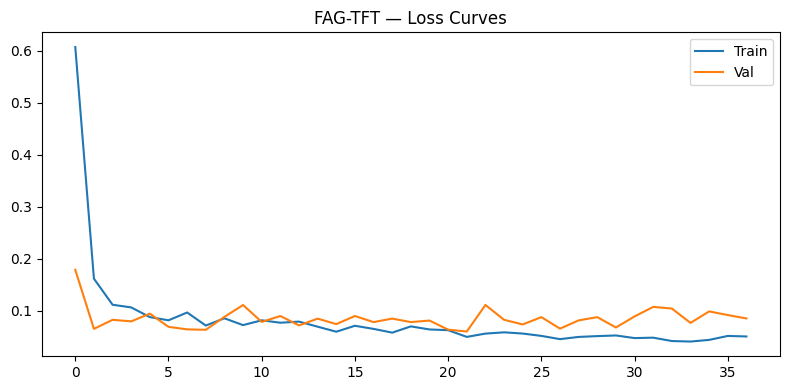

In [4]:
EPOCHS    = 50
optimizer = torch.optim.Adam(tft_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

best_val_loss    = float('inf')
patience_counter = 0
PATIENCE         = 15
train_losses, val_losses = [], []

print('Training FAG-TFT Classifier...')
for epoch in range(EPOCHS):
    tft_model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(tft_model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tft_model.parameters(), 0.5)
        optimizer.step()
        batch_losses.append(loss.item())
    scheduler.step()

    tft_model.eval()
    with torch.no_grad():
        val_loss = criterion(tft_model(X_test), y_test).item()
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(tft_model.state_dict(), 'best_fag_tft.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

tft_model.load_state_dict(torch.load('best_fag_tft.pt'))
print(f'\n✅ Best val loss: {best_val_loss:.4f} — best checkpoint restored.')

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('FAG-TFT — Loss Curves')
plt.legend(); plt.tight_layout()
plt.savefig('fag_tft_loss.png', dpi=150); plt.show()


#### Evaluate FAG-TFT


FAG-TFT RESULTS
Accuracy : 99.26%
F1 Score : 0.9928
RMSE     : 0.1977
MAE      : 0.0158

                        precision    recall  f1-score   support

               Healthy       1.00      0.99      1.00      9397
   High Thread Tension       0.90      1.00      0.95       197
    High foot pressure       0.89      1.00      0.94       169
Running with no thread       0.87      1.00      0.93       217

              accuracy                           0.99      9980
             macro avg       0.92      1.00      0.95      9980
          weighted avg       0.99      0.99      0.99      9980



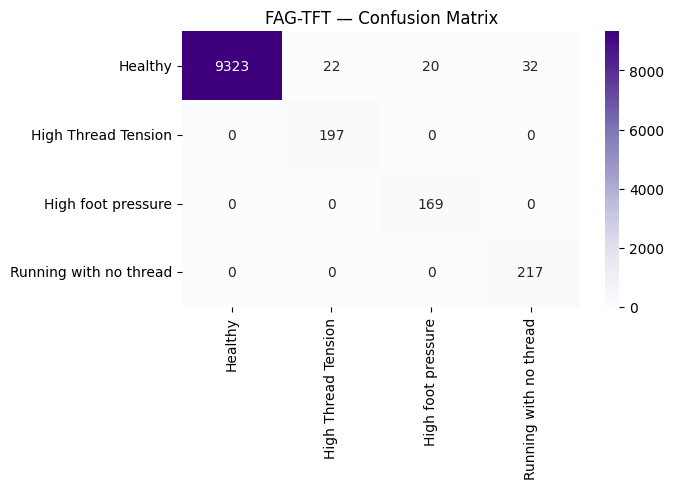

In [5]:
tft_model.load_state_dict(torch.load('best_fag_tft.pt'))
tft_model.eval()
with torch.no_grad():
    logits = tft_model(X_test)
    probs  = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(probs, axis=1)
    y_true = y_test.cpu().numpy()

acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred, average='weighted')
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)

print('='*50)
print('FAG-TFT RESULTS')
print('='*50)
print(f'Accuracy : {acc*100:.2f}%')
print(f'F1 Score : {f1:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'MAE      : {mae:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('FAG-TFT — Confusion Matrix')
plt.tight_layout()
plt.savefig('fag_tft_confusion.png', dpi=150); plt.show()


#### Frequency Group Importance


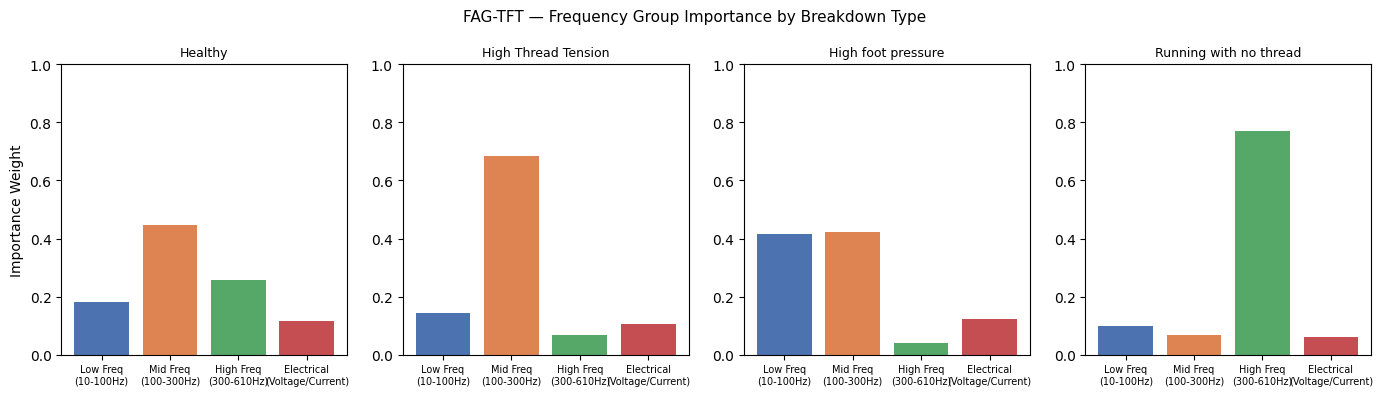

✅ Group importance plot saved.


In [6]:
group_names = ['Low Freq\n(10-100Hz)', 'Mid Freq\n(100-300Hz)',
               'High Freq\n(300-610Hz)', 'Electrical\n(Voltage/Current)']
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']

class_importances = {cls: np.zeros(4) for cls in encoder.classes_}
class_counts_eval = {cls: 0 for cls in encoder.classes_}

tft_model.eval()
with torch.no_grad():
    for i in range(0, len(X_test), 32):
        xb = X_test[i:i+32]
        _  = tft_model(xb)
        gw = tft_model.vsn.group_weights.numpy()
        yb = y_true[i:i+len(xb)]
        for j, cls_idx in enumerate(yb):
            cls_name = encoder.classes_[cls_idx]
            class_importances[cls_name] += gw[j]
            class_counts_eval[cls_name] += 1

for cls in encoder.classes_:
    if class_counts_eval[cls] > 0:
        class_importances[cls] /= class_counts_eval[cls]

fig, axes = plt.subplots(1, len(encoder.classes_), figsize=(14, 4))
axes = np.atleast_1d(axes)
for idx, cls in enumerate(encoder.classes_):
    axes[idx].bar(group_names, class_importances[cls], color=colors)
    axes[idx].set_title(cls, fontsize=9)
    axes[idx].set_ylim(0, 1)
    axes[idx].set_ylabel('Importance Weight' if idx==0 else '')
    axes[idx].tick_params(axis='x', labelsize=7)

plt.suptitle('FAG-TFT — Frequency Group Importance by Breakdown Type', fontsize=11)
plt.tight_layout()
plt.savefig('fag_tft_group_importance.png', dpi=150, bbox_inches='tight'); plt.show()
print('✅ Group importance plot saved.')


#### Save Artifacts


In [7]:
tft_results = {'model':'FAG-TFT','accuracy':acc,'f1':f1,'rmse':rmse,'mae':mae}
with open('fag_tft_results.pkl','wb') as f: pickle.dump(tft_results, f)

tft_config = {
    'g1_size'    : len(G1_IDX), 'g2_size': len(G2_IDX),
    'g3_size'    : len(G3_IDX), 'el_size': len(EL_IDX),
    'time_steps' : TIME_STEPS,  'num_classes': NUM_CLASSES,
    'hidden_size': 16,          'num_heads': 2,
    'G1_IDX'     : G1_IDX,      'G2_IDX': G2_IDX,
    'G3_IDX'     : G3_IDX,      'EL_IDX': EL_IDX,
}
with open('tft_config.pkl','wb') as f: pickle.dump(tft_config, f)

print('✅ Saved: best_anomaly_gate.pt | best_fag_tft.pt | ae_thresholds.pkl | fag_tft_results.pkl | tft_config.pkl')
print(f'\nFinal FAG-TFT Accuracy: {acc*100:.2f}%')


✅ Saved: best_anomaly_gate.pt | best_fag_tft.pt | ae_thresholds.pkl | fag_tft_results.pkl | tft_config.pkl

Final FAG-TFT Accuracy: 99.26%
